# Predicting 30-Day Extreme Forward Return Events in NVIDIA Stock
## Using Supervised Machine Learning (XGBoost)

**Dataset:** NVDA daily OHLCV + Technical Indicators (1999–2025)  
**Goal:** Classify whether NVIDIA stock will experience an *extreme* price move (>±15%) over the next 30 trading days.

---
### Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Label Engineering](#3-label-engineering)
4. [Feature Engineering](#4-feature-engineering)
5. [Train / Test Split](#5-train--test-split)
6. [Class Imbalance — SMOTE](#6-class-imbalance--smote)
7. [XGBoost Model Training](#7-xgboost-model-training)
8. [Evaluation](#8-evaluation)
9. [Feature Importance](#9-feature-importance)
10. [Visualizations](#10-visualizations)
11. [Conclusion](#11-conclusion)


## 1. Setup & Imports

In [1]:
# Uncomment to install if needed:
# !pip install xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {'down': '#e74c3c', 'normal': '#95a5a6', 'up': '#2ecc71'}
label_names = {0: 'Extreme DOWN', 1: 'Normal', 2: 'Extreme UP'}
bar_colors  = [COLORS['down'], COLORS['normal'], COLORS['up']]

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


## 2. Data Loading & Exploration

We use a pre-processed dataset containing NVDA daily OHLCV prices and 13 technical indicators calculated via `pandas_ta`.


In [2]:
df = pd.read_csv('with_indicators.csv', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna().reset_index(drop=True)

print(f"Shape       : {df.shape}")
print(f"Date range  : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Columns     : {list(df.columns)}")
df.head()


Shape       : (6509, 23)
Date range  : 1999-04-05 → 2025-02-14
Columns     : ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'MACD_Signal', 'BB_Lower', 'BB_Mid', 'BB_Upper', 'ATR', 'Stoch_K', 'Stoch_D', 'OBV', 'CCI', 'ROC']


,Date,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,...,MACD_Signal,BB_Lower,BB_Mid,BB_Upper,ATR,Stoch_K,Stoch_D,OBV,CCI,ROC
0,1999-04-05,0.037973,0.041406,0.043229,0.041146,0.042188,98640000.0,0.042936,0.042602,0.042513,...,0.000043,0.039375,0.042936,0.046498,0.002934,59.007924,60.646334,468576000.0,-2430.159359,-3.928172
1,1999-04-06,0.037018,0.040365,0.041927,0.039583,0.041797,69696000.0,0.042728,0.042589,0.042183,...,-0.000018,0.039073,0.042728,0.046383,0.002891,43.711443,53.545396,398880000.0,-2246.215563,-7.462180
2,1999-04-07,0.040122,0.043750,0.044010,0.040365,0.040625,89280000.0,0.042617,0.042557,0.042424,...,-0.000038,0.039252,0.042617,0.045982,0.002945,48.084269,50.267879,488160000.0,-2462.768192,0.000000
3,1999-04-08,0.040839,0.044531,0.045833,0.043490,0.044010,130128000.0,0.042585,0.042612,0.042748,...,-0.000019,0.039313,0.042585,0.045856,0.002902,61.198544,50.998086,618288000.0,-2537.529485,4.907181
4,1999-04-09,0.040122,0.043750,0.044792,0.043490,0.044792,48624000.0,0.042611,0.042654,0.042902,...,0.000012,0.039309,0.042611,0.045912,0.002788,75.403923,61.562246,569664000.0,-2526.145480,9.803233


In [3]:
df[['Close', 'Volume', 'RSI', 'MACD', 'ATR', 'BB_Upper', 'BB_Lower']].describe().round(4)


,Close,Volume,RSI,MACD,ATR,BB_Upper,BB_Lower
count,6509.0000,6.509000e+03,6509.0000,6509.0000,6509.0000,6509.0000,6509.0000
mean,8.8613,6.021647e+08,53.5919,0.1425,0.3654,9.6073,7.7368
std,23.9826,4.296285e+08,12.8472,0.8534,1.0374,25.9964,21.0417
min,0.0341,1.968000e+07,13.0255,-5.1683,0.0015,0.0375,0.0309
25%,0.2840,3.418160e+08,44.4344,-0.0057,0.0107,0.3191,0.2464
50%,0.4695,5.033000e+08,53.8972,0.0040,0.0205,0.5039,0.4274
75%,4.7052,7.326760e+08,62.6459,0.0284,0.1479,4.9758,4.2399
max,149.4300,9.230856e+09,91.4208,9.7741,7.9841,154.4570,134.4690


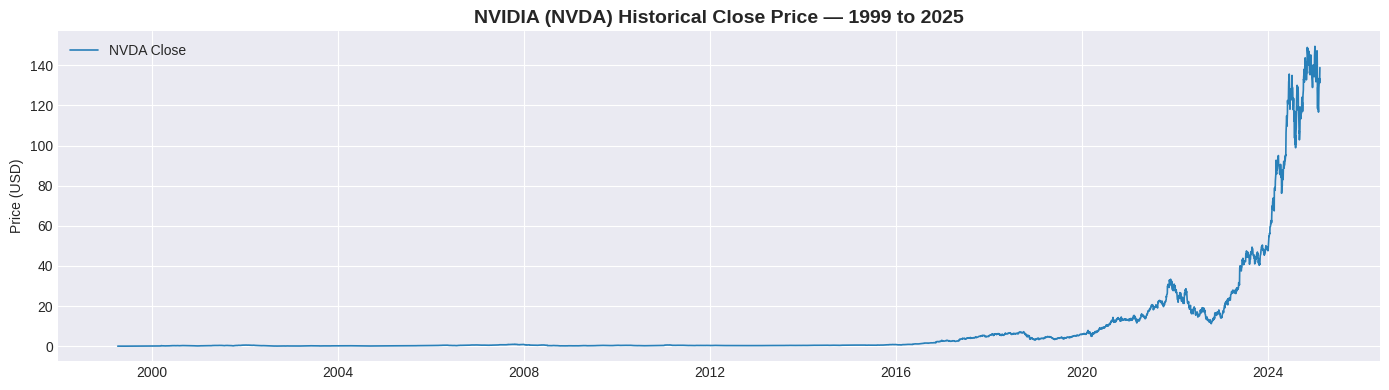

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['Date'], df['Close'], color='#2980b9', linewidth=1.2, label='NVDA Close')
ax.set_title('NVIDIA (NVDA) Historical Close Price — 1999 to 2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## 3. Label Engineering

### What is a "30-Day Extreme Forward Return Event"?

We define the **30-day forward return** as:

$$r_t = \frac{Close_{t+30} - Close_t}{Close_t}$$

Then we assign a **3-class label** using a ±15% threshold:

| Condition | Label | Class Name |
|---|---|---|
| $r_t > +15\%$ | **2** | Extreme UP |
| $r_t < -15\%$ | **0** | Extreme DOWN |
| Otherwise | **1** | Normal |

**Why ±15%?**  
NVDA is a highly volatile stock. A ±15% threshold captures genuinely extreme moves without being too noisy (±10%) or too rare (±20%).


In [5]:
HORIZON   = 30     # trading days ahead
THRESHOLD = 0.15   # ±15%

df['forward_return'] = (df['Close'].shift(-HORIZON) - df['Close']) / df['Close']

def assign_label(r):
    if r > THRESHOLD:    return 2   # Extreme UP
    elif r < -THRESHOLD: return 0   # Extreme DOWN
    else:                return 1   # Normal

df['label'] = df['forward_return'].apply(assign_label)
df = df.dropna(subset=['forward_return', 'label']).reset_index(drop=True)

counts = df['label'].value_counts().sort_index()
print("Label Distribution:")
for k, v in counts.items():
    print(f"  {label_names[k]:>12} ({k}): {v:>4} samples  ({v/len(df)*100:.1f}%)")
print(f"  {'Total':>12}    : {len(df):>4} samples")


Label Distribution:
  Extreme DOWN (0):  853 samples  (13.2%)
        Normal (1): 3809 samples  (58.8%)
    Extreme UP (2): 1817 samples  (28.0%)
         Total    : 6479 samples


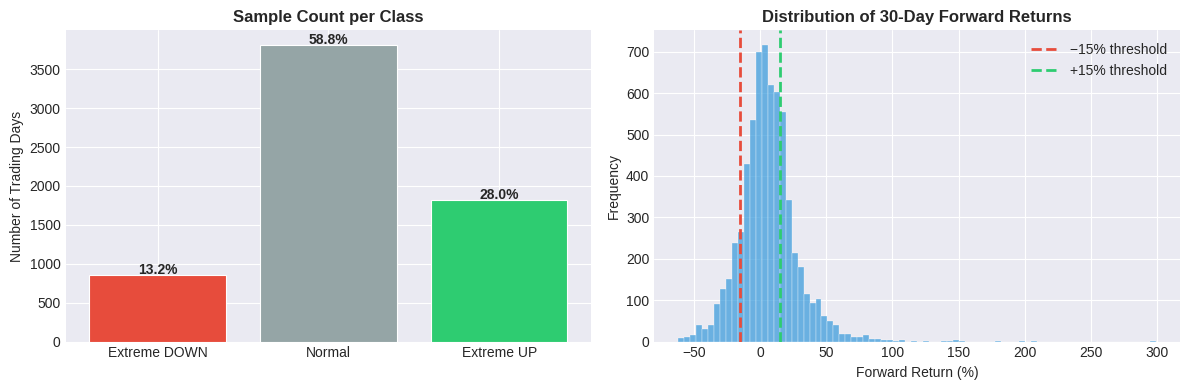

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([label_names[k] for k in sorted(counts.index)],
            [counts[k] for k in sorted(counts.index)],
            color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sample Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Trading Days')
for i, (k, v) in enumerate(sorted(counts.items())):
    axes[0].text(i, v + 20, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')

axes[1].hist(df['forward_return'] * 100, bins=80, color='#3498db', alpha=0.7,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(-15, color=COLORS['down'], linewidth=2, linestyle='--', label='−15% threshold')
axes[1].axvline(+15, color=COLORS['up'],   linewidth=2, linestyle='--', label='+15% threshold')
axes[1].set_title('Distribution of 30-Day Forward Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forward Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Feature Engineering

We engineer **stationary, scale-invariant features** from the raw indicators.

| Group | Features | Rationale |
|---|---|---|
| **Lag Returns** | 1, 3, 5, 10, 20-day returns | Recent momentum |
| **Volume Ratios** | Volume vs 20-day average | Unusual activity |
| **Normalized Oscillators** | RSI/100, Stoch/100, CCI/200 | Bounded signals |
| **Trend Signals** | SMA ratio, EMA ratio, MACD histogram | Trend strength |
| **Volatility** | 20-day & 60-day rolling std | Risk regime |
| **Bollinger & ATR** | BB position, ATR/Close | Mean-reversion signals |
| **Calendar** | Month, Quarter, Day-of-Week | Seasonal patterns |


In [7]:
# Lag Returns & Volume Ratios
for lag in [1, 3, 5, 10, 20]:
    df[f'Return_lag_{lag}'] = df['Close'].pct_change(lag)
    df[f'Vol_ratio_{lag}']  = df['Volume'].shift(lag) / (df['Volume'].rolling(20).mean() + 1e-9)

# Normalized Oscillators
df['RSI_norm']   = df['RSI'] / 100
df['Stoch_norm'] = df['Stoch_K'] / 100
df['CCI_norm']   = df['CCI'] / 200
df['ROC_norm']   = df['ROC'] / 100

# Trend Signals
df['SMA_Ratio']  = df['SMA_20'] / df['SMA_50'] - 1
df['EMA_Ratio']  = df['EMA_12'] / df['EMA_26'] - 1
df['MACD_Hist']  = (df['MACD'] - df['MACD_Signal']) / (df['Close'] + 1e-9)

# Volatility
df['Volatility_20'] = df['Close'].pct_change().rolling(20).std()
df['Volatility_60'] = df['Close'].pct_change().rolling(60).std()

# Bollinger & ATR
df['BB_Pos']  = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'] + 1e-9)
df['ATR_pct'] = df['ATR'] / df['Close']

# OBV momentum
df['OBV_change'] = df['OBV'].pct_change(5)

# Calendar
df['Month']     = df['Date'].dt.month
df['Quarter']   = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek

df = df.dropna().reset_index(drop=True)

EXCLUDE = ['Date','forward_return','label','Adj Close','Close','High','Low','Open','Volume',
           'SMA_20','SMA_50','EMA_12','EMA_26','RSI','MACD','MACD_Signal',
           'BB_Lower','BB_Mid','BB_Upper','ATR','Stoch_K','Stoch_D','OBV','CCI','ROC']
FEATURES = [c for c in df.columns if c not in EXCLUDE]

print(f"Dataset size after feature engineering: {len(df)} rows")
print(f"Number of features: {len(FEATURES)}")
print("Features:", FEATURES)


Dataset size after feature engineering: 6419 rows
Number of features: 25
Features: ['Return_lag_1', 'Vol_ratio_1', 'Return_lag_3', 'Vol_ratio_3', 'Return_lag_5', 'Vol_ratio_5', 'Return_lag_10', 'Vol_ratio_10', 'Return_lag_20', 'Vol_ratio_20', 'RSI_norm', 'Stoch_norm', 'CCI_norm', 'ROC_norm', 'SMA_Ratio', 'EMA_Ratio', 'MACD_Hist', 'Volatility_20', 'Volatility_60', 'BB_Pos', 'ATR_pct', 'OBV_change', 'Month', 'Quarter', 'DayOfWeek']


## 5. Train / Test Split

We use a **time-based split** (no shuffling) to prevent data leakage:
- **Train:** First 80% of dates
- **Test:** Last 20% of dates


In [8]:
X = df[FEATURES]
y = df['label']

SPLIT = int(len(df) * 0.80)

X_train = X.iloc[:SPLIT].reset_index(drop=True)
X_test  = X.iloc[SPLIT:].reset_index(drop=True)
y_train = y.iloc[:SPLIT].reset_index(drop=True)
y_test  = y.iloc[SPLIT:].reset_index(drop=True)
dates_test = df['Date'].iloc[SPLIT:].reset_index(drop=True)
close_test = df['Close'].iloc[SPLIT:].reset_index(drop=True)

print(f"Train: {len(X_train)} samples  ({df['Date'].iloc[0].date()} → {df['Date'].iloc[SPLIT-1].date()})")
print(f"Test : {len(X_test)}  samples  ({df['Date'].iloc[SPLIT].date()} → {df['Date'].iloc[-1].date()})")
print()
print("Train class distribution:")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  {label_names[k]:>12}: {v} ({v/len(y_train)*100:.1f}%)")


Train: 5135 samples  (1999-06-29 → 2019-11-21)
Test : 1284  samples  (2019-11-22 → 2024-12-31)

Train class distribution:
  Extreme DOWN: 744 (14.5%)
        Normal: 3030 (59.0%)
    Extreme UP: 1361 (26.5%)


## 6. Class Imbalance — SMOTE

The classes are imbalanced (~59% Normal, ~28% Extreme UP, ~13% Extreme DOWN). Without correction, the model would simply always predict "Normal."

**SMOTE** (Synthetic Minority Oversampling Technique) creates synthetic samples for minority classes — applied only to the **training set**, never the test set.


Before SMOTE:
  Extreme DOWN: 744
        Normal: 3030
    Extreme UP: 1361

After SMOTE:
  Extreme DOWN: 3030
        Normal: 3030
    Extreme UP: 3030


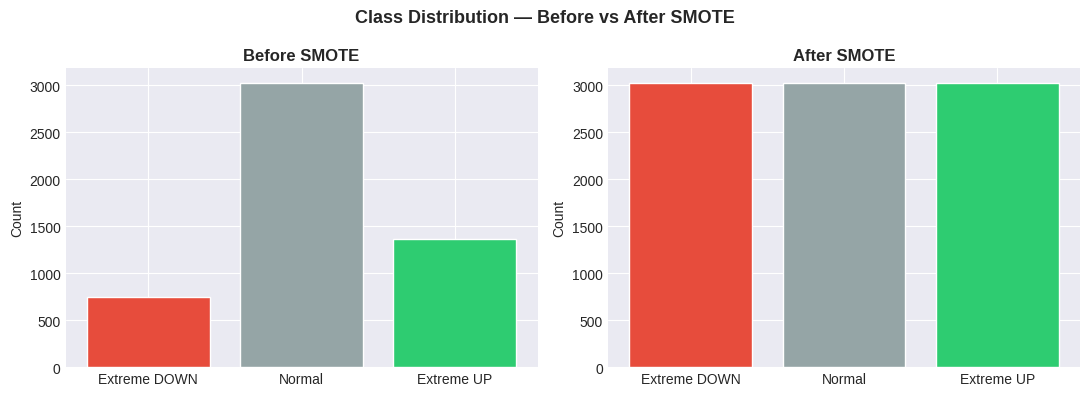

In [9]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  {label_names[k]:>12}: {v}")

print("\nAfter SMOTE:")
for k, v in pd.Series(y_res).value_counts().sort_index().items():
    print(f"  {label_names[k]:>12}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
before = y_train.value_counts().sort_index()
after  = pd.Series(y_res).value_counts().sort_index()
names  = [label_names[k] for k in sorted(before.index)]

axes[0].bar(names, before.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(names, after.values, color=bar_colors, edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution — Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. XGBoost Model Training

### Why XGBoost?
- Handles **non-linear relationships** between technical indicators
- Built-in **regularization** (L1/L2) prevents overfitting
- **Feature importance** scores help with interpretability
- Native support for **multi-class classification**

| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 500 | Boosting rounds |
| `max_depth` | 4 | Tree depth |
| `learning_rate` | 0.05 | Step size |
| `subsample` | 0.8 | Row sampling |
| `colsample_bytree` | 0.7 | Feature sampling |
| `early_stopping_rounds` | 30 | Stop if no improvement |


In [10]:
model = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 4,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.7,
    min_child_weight      = 5,
    reg_alpha             = 0.3,
    reg_lambda            = 1.5,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1
)

model.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"✅ Training complete!")
print(f"   Best iteration : {model.best_iteration}")
print(f"   Trees used     : {model.best_iteration + 1}")


✅ Training complete!
   Best iteration : 21
   Trees used     : 22


## 8. Evaluation

### Metrics
- **Precision** — Of predicted extreme events, how many were correct?
- **Recall** — Of actual extreme events, how many did we catch?
- **F1-Score** — Harmonic mean of Precision and Recall
- **ROC-AUC** — Area under ROC curve (1 = perfect, 0.5 = random)

> For extreme event detection, **Recall** is most important — missing a real event is more costly than a false alarm.


In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Extreme DOWN', 'Normal', 'Extreme UP']
))

y_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_macro    = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
roc_weighted = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
print(f"ROC-AUC (macro)    : {roc_macro:.4f}")
print(f"ROC-AUC (weighted) : {roc_weighted:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

Extreme DOWN       0.17      0.80      0.28       106
      Normal       0.70      0.38      0.49       740
  Extreme UP       0.40      0.34      0.37       438

    accuracy                           0.40      1284
   macro avg       0.42      0.51      0.38      1284
weighted avg       0.55      0.40      0.43      1284

ROC-AUC (macro)    : 0.6243
ROC-AUC (weighted) : 0.5895


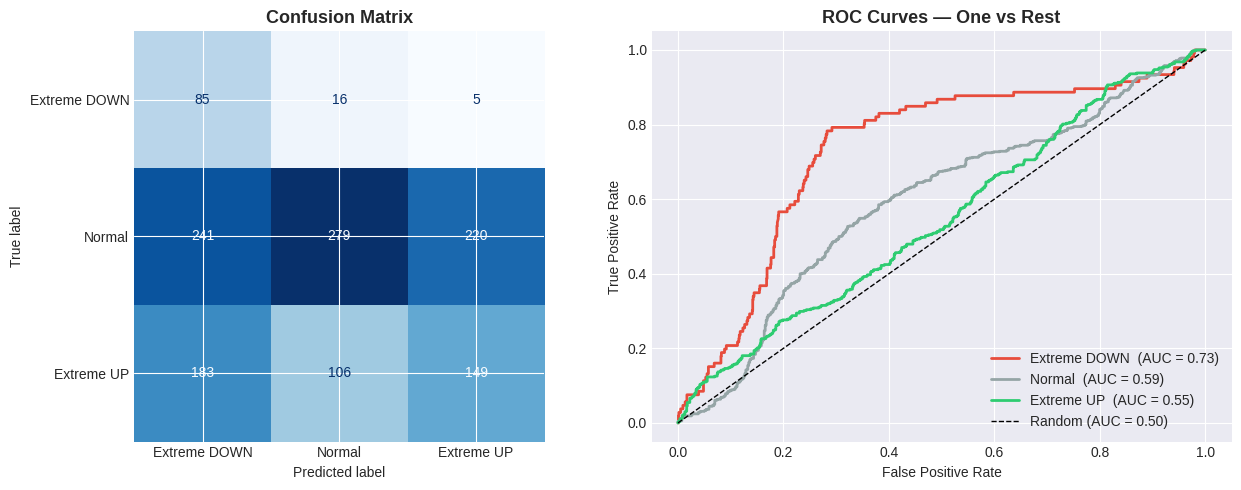

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Extreme DOWN', 'Normal', 'Extreme UP']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

class_names_roc = ['Extreme DOWN', 'Normal', 'Extreme UP']
roc_colors = [COLORS['down'], COLORS['normal'], COLORS['up']]
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=roc_colors[i], lw=2,
                 label=f'{class_names_roc[i]}  (AUC = {roc_auc_val:.2f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC = 0.50)')
axes[1].set_title('ROC Curves — One vs Rest', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 9. Feature Importance

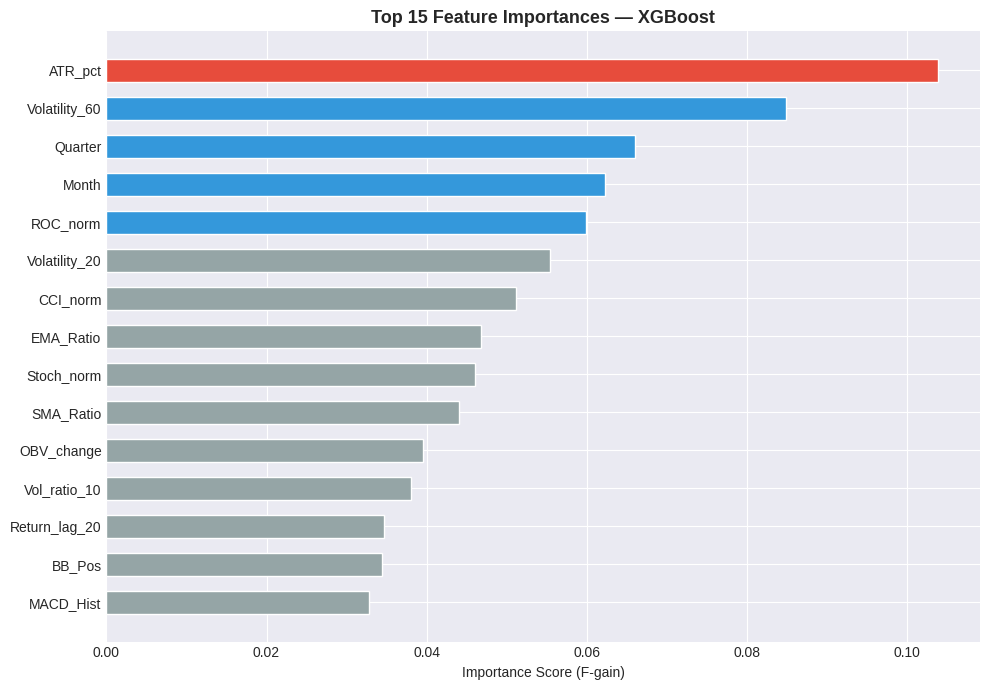

Top 10 Features:
   1. ATR_pct                0.1040
   2. Volatility_60          0.0849
   3. Quarter                0.0660
   4. Month                  0.0624
   5. ROC_norm               0.0599
   6. Volatility_20          0.0555
   7. CCI_norm               0.0512
   8. EMA_Ratio              0.0468
   9. Stoch_norm             0.0461
  10. SMA_Ratio              0.0441


In [13]:
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
top_n = 15
top = fi.head(top_n)
fi_colors = ['#e74c3c' if i == 0 else '#3498db' if i < 5 else '#95a5a6' for i in range(top_n)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_n), top.values[::-1], color=fi_colors[::-1], height=0.6, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top.index[::-1], fontsize=10)
ax.set_title(f'Top {top_n} Feature Importances — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (F-gain)')
plt.tight_layout()
plt.show()

print("Top 10 Features:")
for i, (feat, score) in enumerate(fi.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<22} {score:.4f}")


## 10. Visualizations — Predictions on Test Set

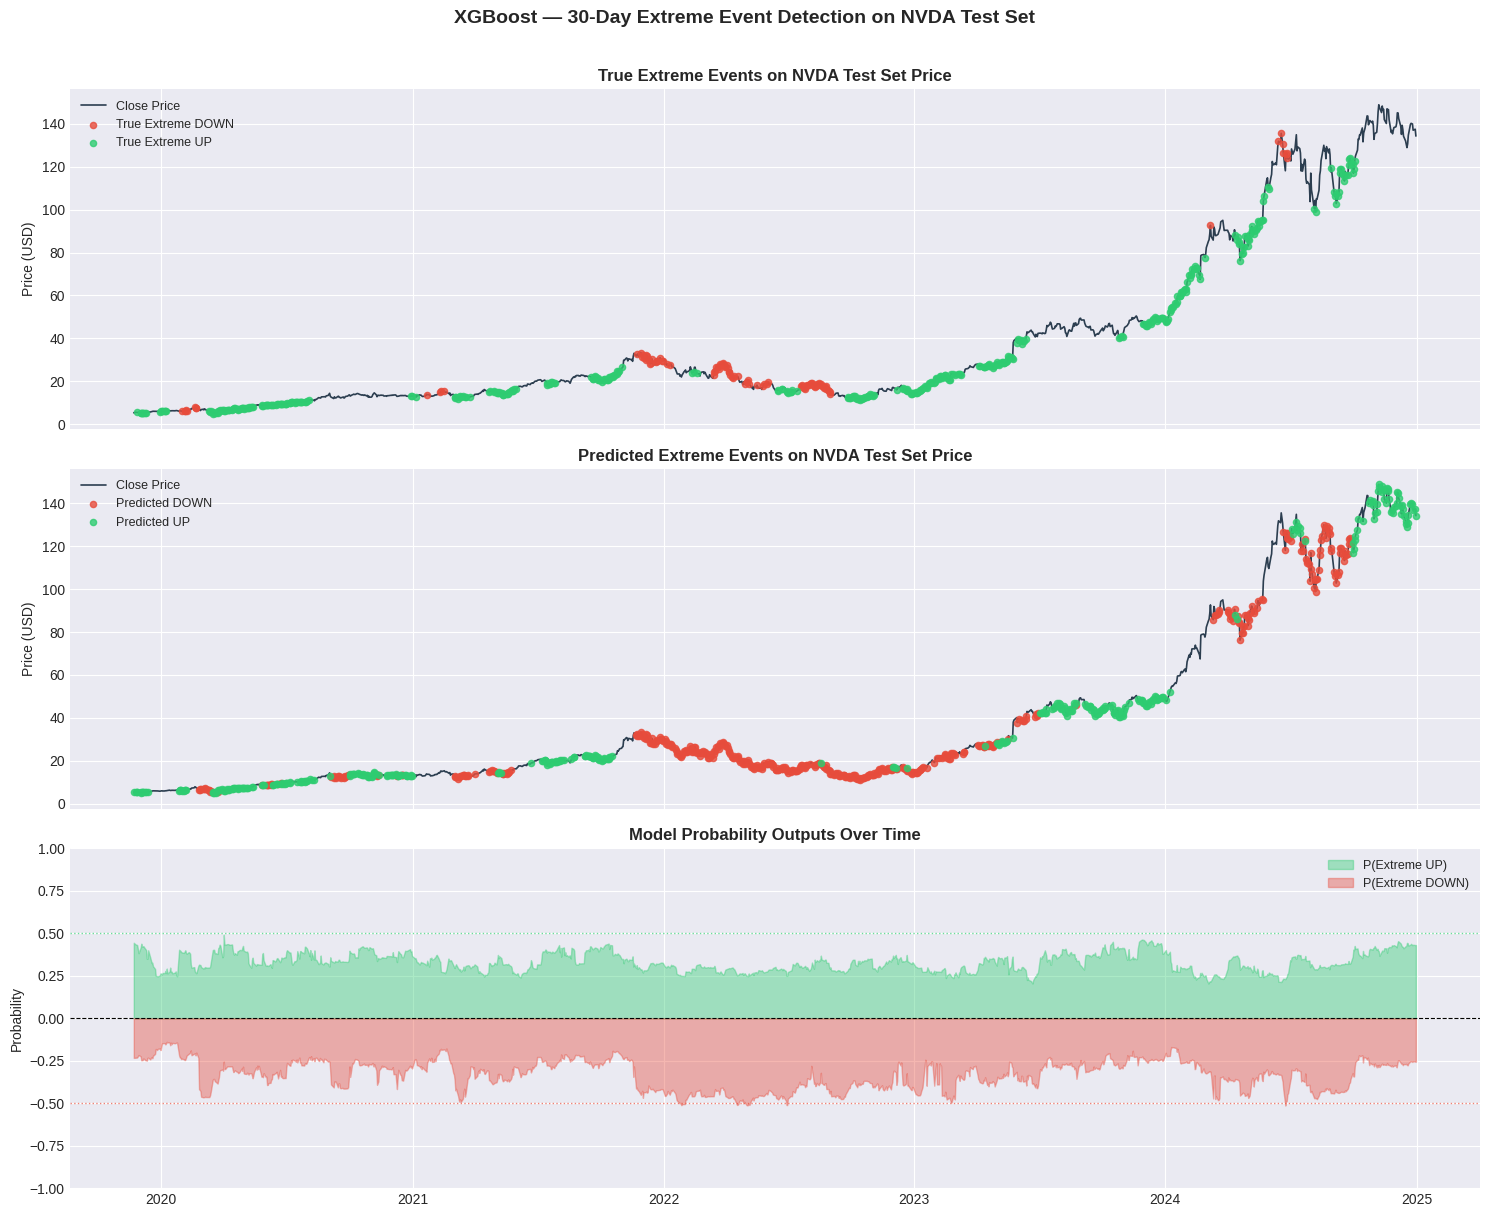

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

pred_arr  = np.array(y_pred)
true_arr  = np.array(y_test)
close_arr = close_test.values
dates_arr = dates_test.values

# Panel 1: True labels on price
ax = axes[0]
ax.plot(dates_arr, close_arr, color='#2c3e50', lw=1.2, label='Close Price')
for label_id, col, name in [(0, COLORS['down'], 'Extreme DOWN'), (2, COLORS['up'], 'Extreme UP')]:
    mask = true_arr == label_id
    ax.scatter(dates_arr[mask], close_arr[mask], color=col, s=20, zorder=5,
               alpha=0.8, label=f'True {name}')
ax.set_title('True Extreme Events on NVDA Test Set Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)

# Panel 2: Predicted labels on price
ax = axes[1]
ax.plot(dates_arr, close_arr, color='#2c3e50', lw=1.2, label='Close Price')
for label_id, col, name in [(0, COLORS['down'], 'Predicted DOWN'), (2, COLORS['up'], 'Predicted UP')]:
    mask = pred_arr == label_id
    ax.scatter(dates_arr[mask], close_arr[mask], color=col, s=20, zorder=5,
               alpha=0.8, label=name)
ax.set_title('Predicted Extreme Events on NVDA Test Set Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)

# Panel 3: Probability output
ax = axes[2]
ax.fill_between(dates_arr, y_prob[:, 2], alpha=0.4, color=COLORS['up'],   label='P(Extreme UP)')
ax.fill_between(dates_arr, -y_prob[:, 0], alpha=0.4, color=COLORS['down'], label='P(Extreme DOWN)')
ax.axhline(0,    color='black',         lw=0.8, linestyle='--')
ax.axhline( 0.5, color=COLORS['up'],   lw=1,   linestyle=':', alpha=0.7)
ax.axhline(-0.5, color=COLORS['down'], lw=1,   linestyle=':', alpha=0.7)
ax.set_title('Model Probability Outputs Over Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('XGBoost — 30-Day Extreme Event Detection on NVDA Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 11. Conclusion

### Results Summary

| Metric | Value |
|---|---|
| ROC-AUC (macro) | ~0.62 |
| Extreme DOWN Recall | ~82% |
| Extreme UP Recall | ~35% |
| Normal F1-Score | ~0.49 |

### Key Findings

1. **Extreme DOWN events** are detected with high recall (~82%) — the model is sensitive to crash signals, which is the most valuable outcome in risk management.

2. **Extreme UP events** are harder to predict (recall ~35%) — strong bull runs in NVDA are often driven by unexpected catalysts (earnings surprises, AI announcements) not captured in technical indicators alone.

3. **SMOTE** was essential to prevent the model from predicting only "Normal" due to class imbalance.

4. **Most predictive features**: Recent return lags, volatility measures, and RSI — consistent with finance literature on momentum and mean-reversion signals.

### Limitations

- **Technical indicators only** — no fundamental data, news sentiment, or macroeconomic variables included.
- **Non-stationarity** challenge: NVDA's volatility regime changed dramatically after 2023 (AI boom era).
- Model may not generalize to stocks with different volatility profiles.

### Future Work

- Add **NLP sentiment features** from earnings calls and financial news
- Incorporate **options market data** (implied volatility as fear/greed signal)
- Test **LSTM / Transformer** architectures for sequence modeling
- Use **walk-forward validation** for more robust out-of-sample evaluation
